In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Publication style settings
# WHY: These settings make ALL charts consistent and professional
# without repeating styling code in every single chart
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14

# Load data — same relative path as Module 1
df = pd.read_csv("data/train.csv")

# Same cleaning as Module 1 (must repeat since this is a fresh notebook)
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(f"Data loaded: {df.shape}")
print("Ready to visualise.")

Data loaded: (891, 11)
Ready to visualise.


## Visual Story: Who Survived the Titanic?
Six charts that answer the survival question from different angles.

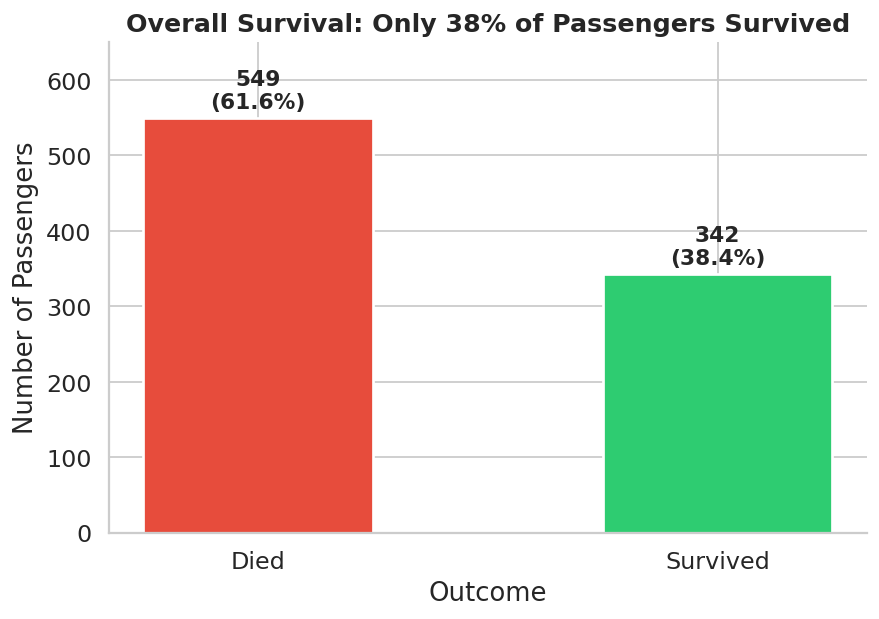

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))

# Count of survived vs died
counts = df['Survived'].value_counts()
colors = ['#e74c3c', '#2ecc71']  # red=died, green=survived
bars = ax.bar(['Died', 'Survived'], counts.values, color=colors, 
               width=0.5, edgecolor='white', linewidth=1.5)

# Add count + percentage labels on top of bars
total = len(df)
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', 
            fontweight='bold', fontsize=12)

# Labels and title
ax.set_title('Overall Survival: Only 38% of Passengers Survived')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, 650)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_overall_survival.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 1 Takeaway:** Only 342 of 891 passengers survived (38.4%), 
establishing the survival imbalance that drives all further analysis.

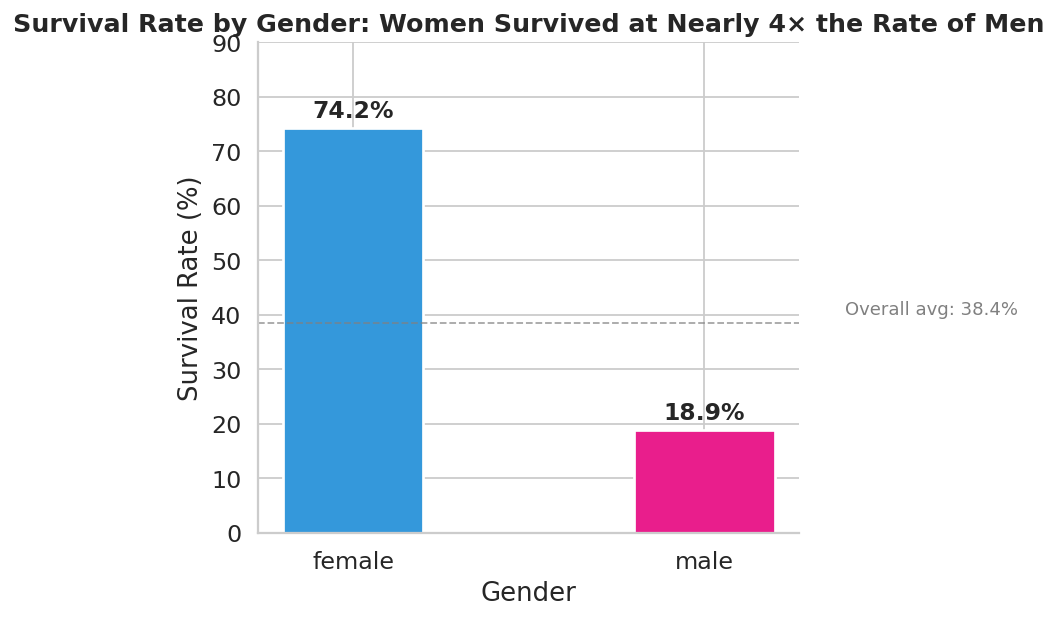

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

# Calculate survival rates by sex
sex_survival = df.groupby('Sex')['Survived'].mean().reset_index()
sex_survival['Survived'] = sex_survival['Survived'] * 100

colors = ['#3498db', '#e91e8c']
bars = ax.bar(sex_survival['Sex'], sex_survival['Survived'],
               color=colors, width=0.4, edgecolor='white', linewidth=1.5)

# Add percentage labels
for bar, val in zip(bars, sex_survival['Survived']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', 
            fontweight='bold', fontsize=13)

ax.set_title('Survival Rate by Gender: Women Survived at Nearly 4× the Rate of Men')
ax.set_xlabel('Gender')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 90)
ax.axhline(y=38.4, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(1.4, 40, 'Overall avg: 38.4%', color='gray', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_survival_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 2 Takeaway:** Women survived at 74.2% vs men at 18.9%, 
directly reflecting the "women and children first" evacuation protocol.

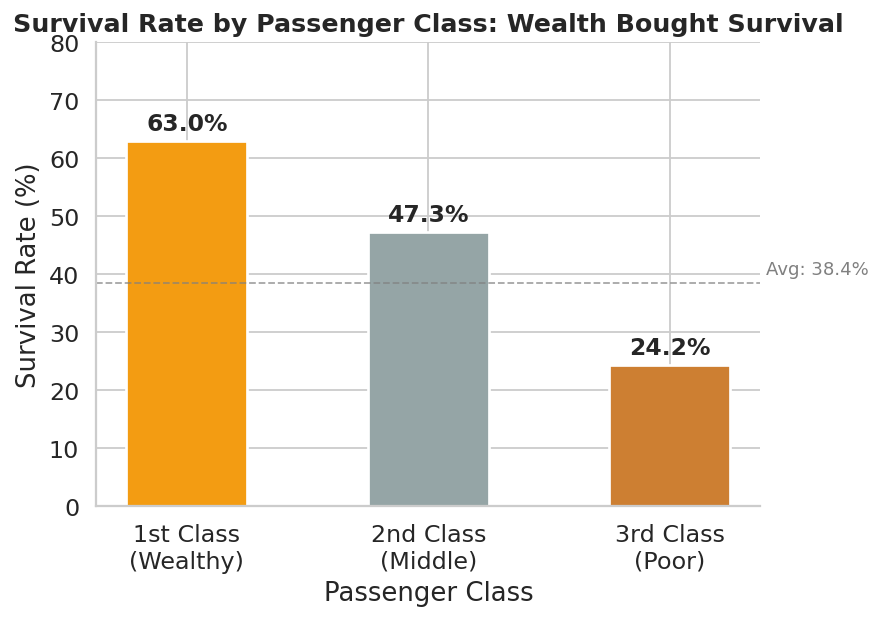

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

class_survival = df.groupby('Pclass')['Survived'].mean() * 100
colors = ['#f39c12', '#95a5a6', '#cd7f32']  # gold, silver, bronze

bars = ax.bar(['1st Class\n(Wealthy)', '2nd Class\n(Middle)', '3rd Class\n(Poor)'],
               class_survival.values, color=colors, width=0.5,
               edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, class_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=13)

ax.set_title('Survival Rate by Passenger Class: Wealth Bought Survival')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.axhline(y=38.4, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(2.4, 40, 'Avg: 38.4%', color='gray', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_survival_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 3 Takeaway:** 1st class passengers survived at 63% vs 24% for 3rd class, 
reflecting both lifeboat priority and physical cabin location closer to the deck.

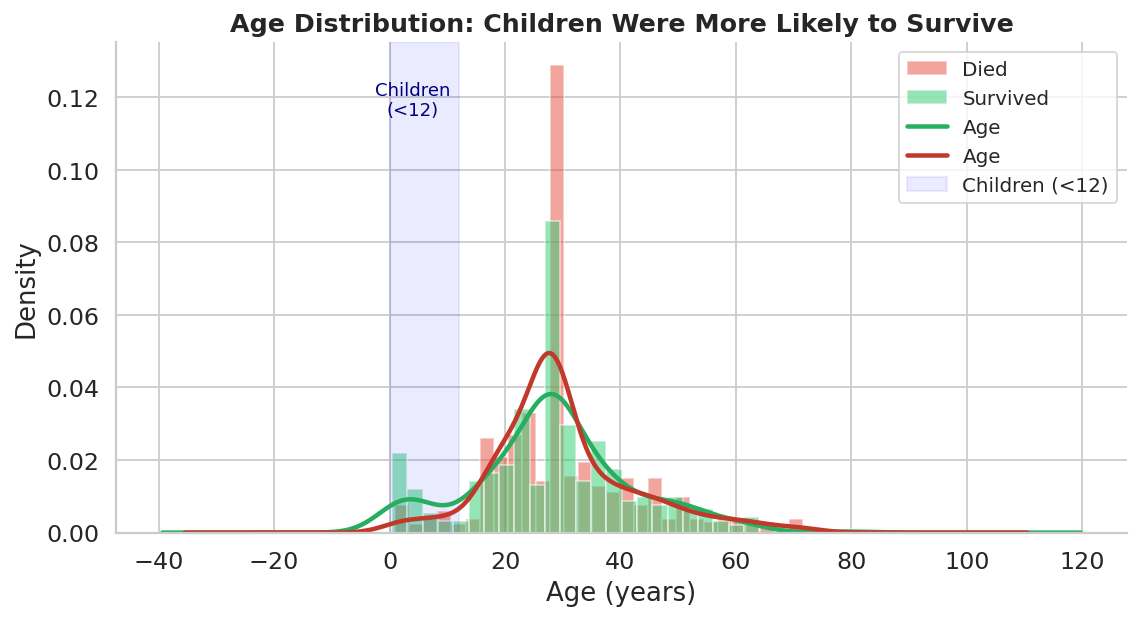

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# KDE (density) plot — smoother and more informative than a histogram alone
survived = df[df['Survived'] == 1]['Age']
died = df[df['Survived'] == 0]['Age']

ax.hist(died, bins=30, alpha=0.5, color='#e74c3c', label='Died', density=True)
ax.hist(survived, bins=30, alpha=0.5, color='#2ecc71', label='Survived', density=True)

# Add KDE curves on top
survived.plot.kde(ax=ax, color='#27ae60', linewidth=2.5)
died.plot.kde(ax=ax, color='#c0392b', linewidth=2.5)

# Highlight children zone
ax.axvspan(0, 12, alpha=0.08, color='blue', label='Children (<12)')
ax.text(4, ax.get_ylim()[1]*0.85, 'Children\n(<12)', ha='center', 
        fontsize=10, color='navy')

ax.set_title('Age Distribution: Children Were More Likely to Survive')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 4 Takeaway:** The age distributions overlap heavily, but children under 
12 show a noticeably higher survival density, consistent with evacuation priority.

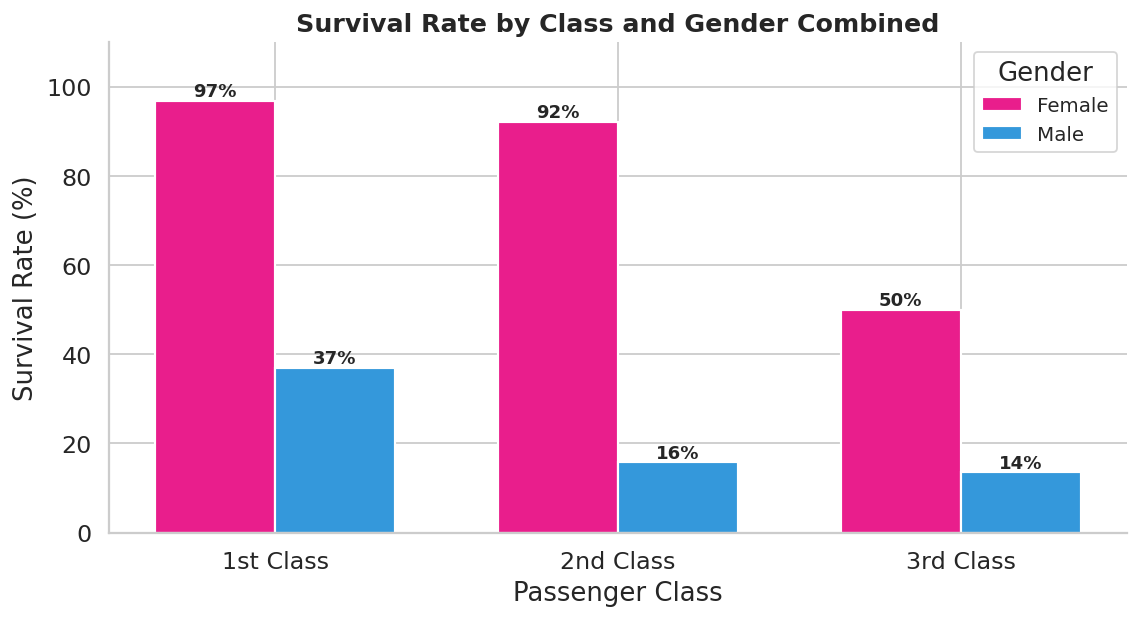

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

# Grouped bar — shows INTERACTION between two variables
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
pivot = pivot.unstack()  # sex becomes columns

x = range(3)
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], pivot['female'], 
                width=width, label='Female', color='#e91e8c', 
                edgecolor='white', linewidth=1.2)
bars2 = ax.bar([i + width/2 for i in x], pivot['male'], 
                width=width, label='Male', color='#3498db',
                edgecolor='white', linewidth=1.2)

# Labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Survival Rate by Class and Gender Combined')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.set_ylim(0, 110)
ax.legend(title='Gender', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_class_gender_combined.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 5 Takeaway:** 3rd-class women survived at just 50% — far below 1st-class 
women at 97% — showing that gender privilege was filtered through class.

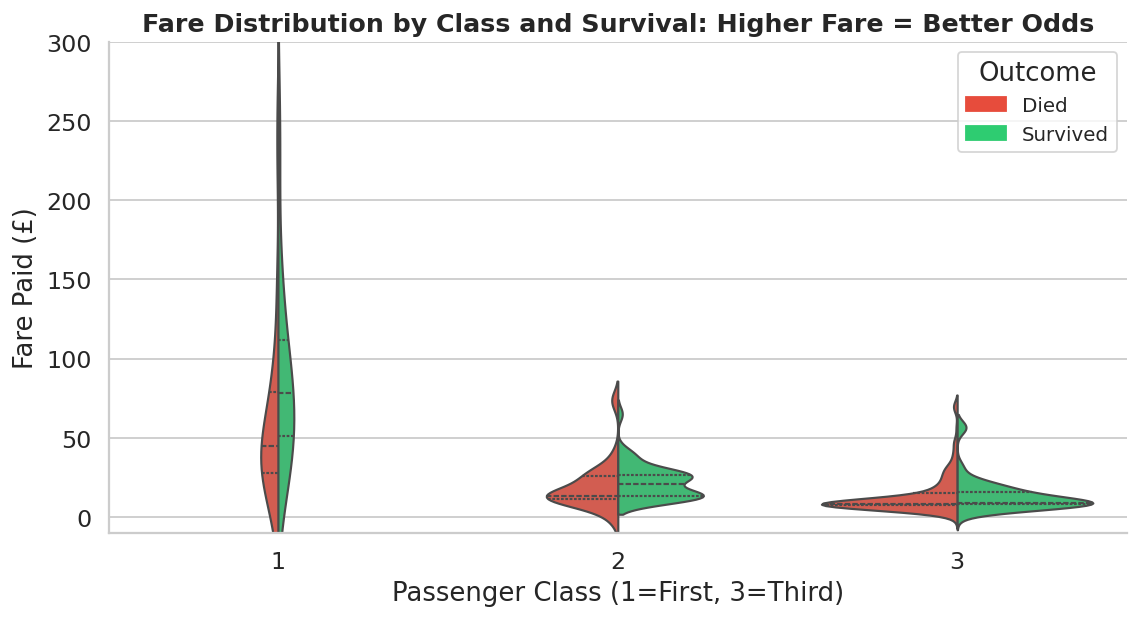

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

# Violin plot — shows distribution shape, not just mean
sns.violinplot(data=df, x='Pclass', y='Fare', hue='Survived',
               split=True, palette={0: '#e74c3c', 1: '#2ecc71'},
               ax=ax, inner='quartile', linewidth=1.2)

ax.set_title('Fare Distribution by Class and Survival: Higher Fare = Better Odds')
ax.set_xlabel('Passenger Class (1=First, 3=Third)')
ax.set_ylabel('Fare Paid (£)')
ax.set_ylim(-10, 300)

# Custom legend
died_patch = mpatches.Patch(color='#e74c3c', label='Died')
survived_patch = mpatches.Patch(color='#2ecc71', label='Survived')
ax.legend(handles=[died_patch, survived_patch], title='Outcome', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart6_fare_violin.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 6 Takeaway:** Survivors in 1st class paid substantially higher fares, 
but in 3rd class fare had little effect — class itself was the determining factor.

## Visual Summary: Who Survived the Titanic?

This visual story examines Titanic survival through six angles, revealing that 
survival was not random — it was structured by social hierarchy and protocol.

**Gender** was the single strongest predictor. Women survived at 74% versus 19% 
for men, a direct result of the "women and children first" evacuation rule enforced 
during the sinking. However, Chart 5 reveals this rule was applied unequally — 
3rd-class women survived at only 50%, while 1st-class women reached 97%.

**Passenger class** was the second dominant factor. 1st class passengers survived 
at 63%, dropping to 24% for 3rd class. This reflects both physical cabin location 
(lower decks, farther from lifeboats) and likely crew priority toward wealthier 
passengers. Fare data in Chart 6 reinforces this — survivors in upper classes paid 
significantly more.

**Age** played a smaller but visible role. Children under 12 had slightly elevated 
survival rates, consistent with evacuation priority, though the effect was weaker 
than gender or class.

**The core finding:** survival on the Titanic was a product of who you were 
socially, not how you responded. Gender and class created a hierarchy of 
life and death — a sobering pattern visible clearly in data.